In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif

In [2]:
Data = pd.read_csv('diabetes.csv')
Data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
Data.shape

(768, 9)

In [4]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
Data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
## Check the missing values
Data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
## Check the duplicated
Data.duplicated().sum()

np.int64(0)

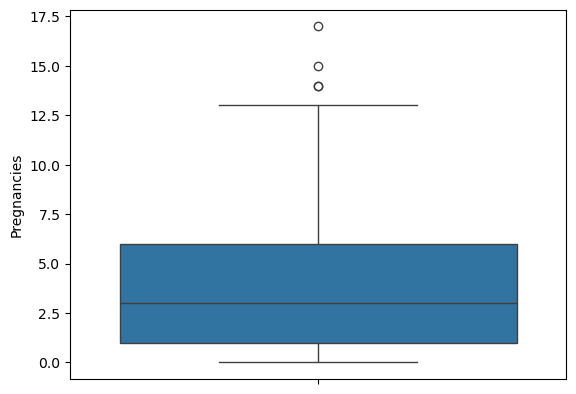

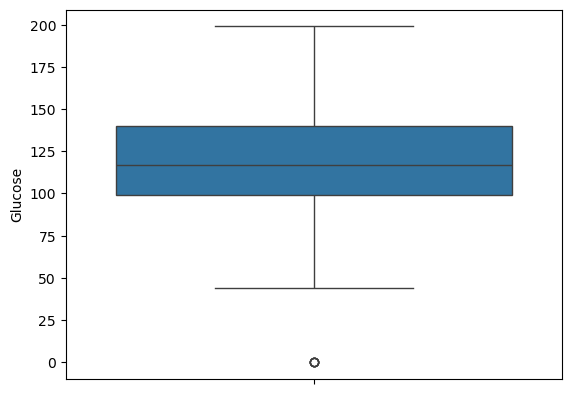

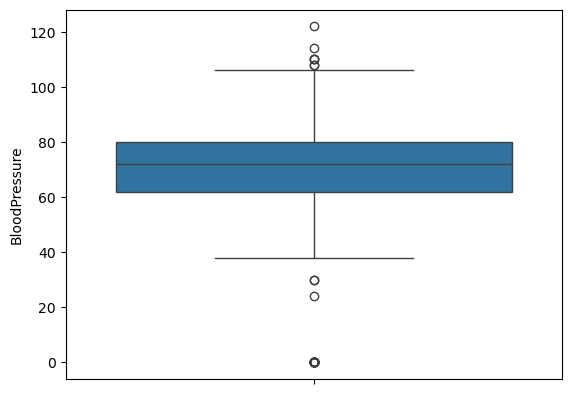

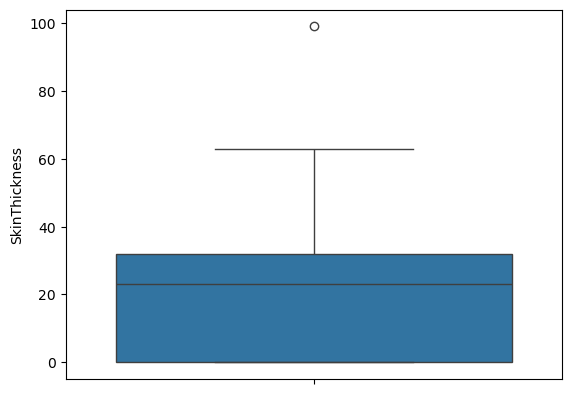

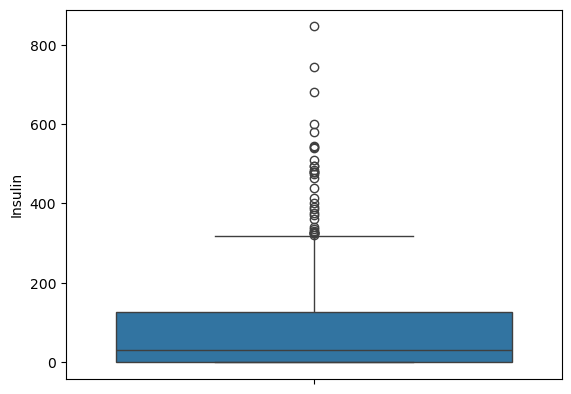

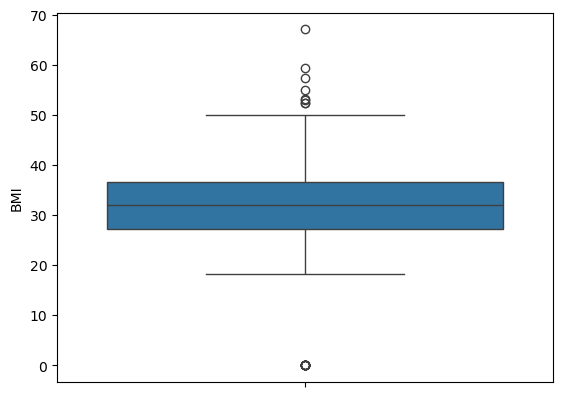

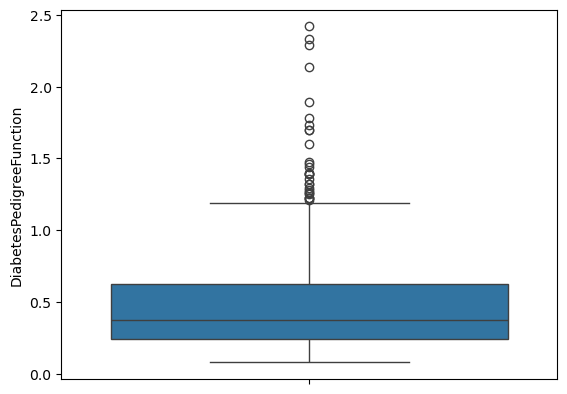

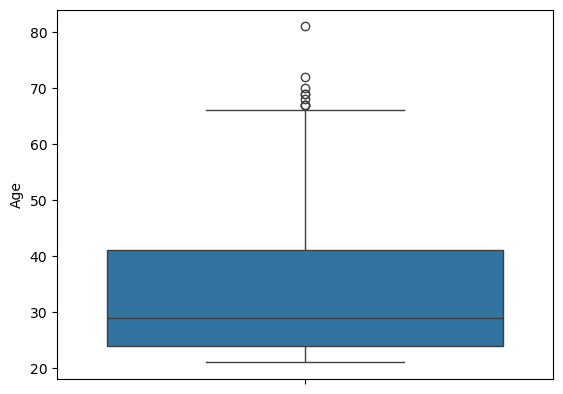

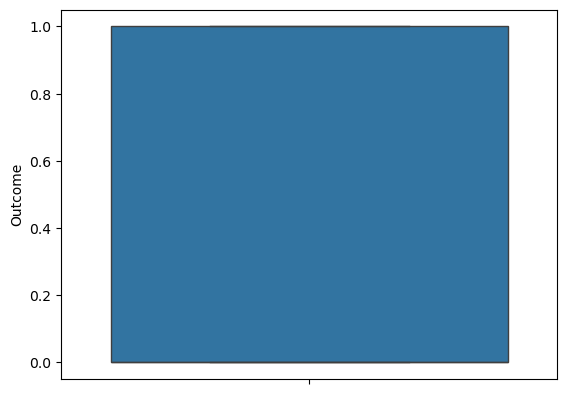

In [8]:
## Check the outliers
for col in Data.columns:
    sns.boxplot(data=Data,y=col)
    plt.show()

In [9]:
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[columns]= df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in Data.select_dtypes(include=['int','float']).columns:
    outlier_capping(Data,col)

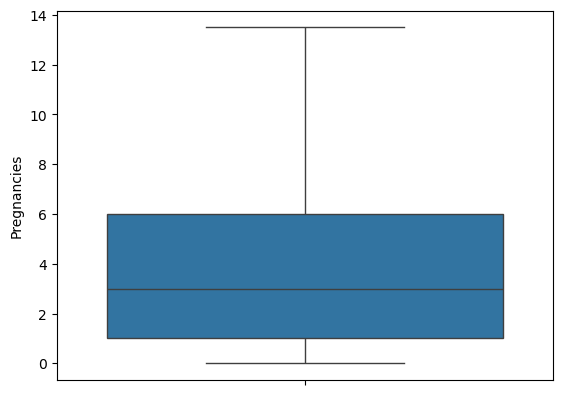

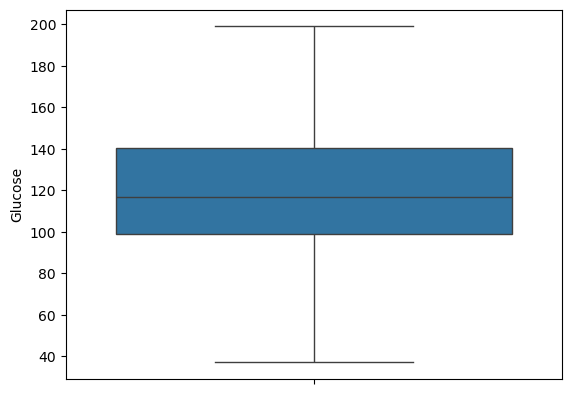

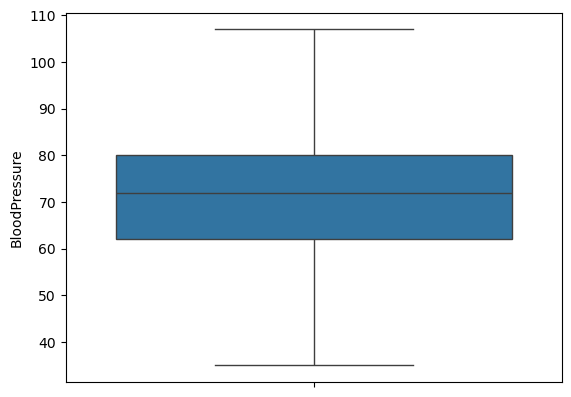

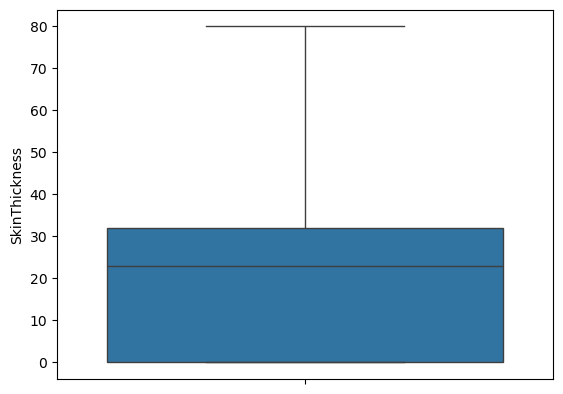

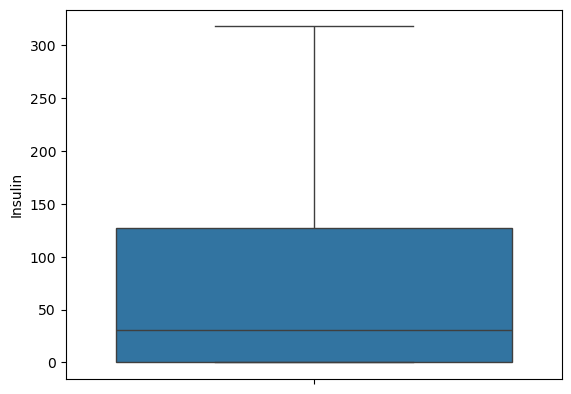

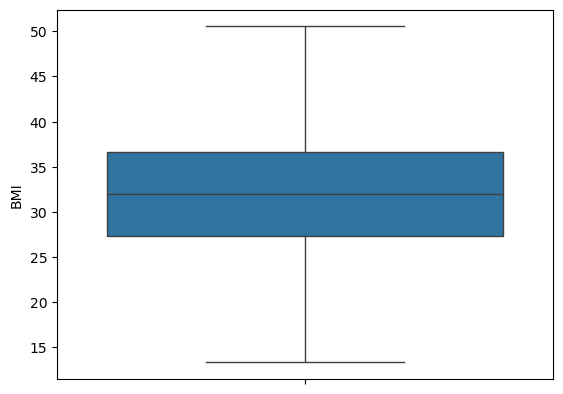

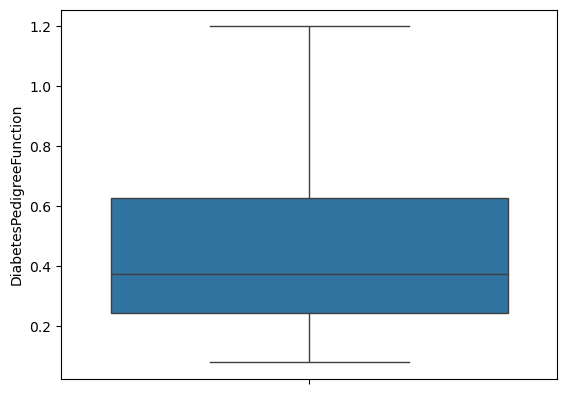

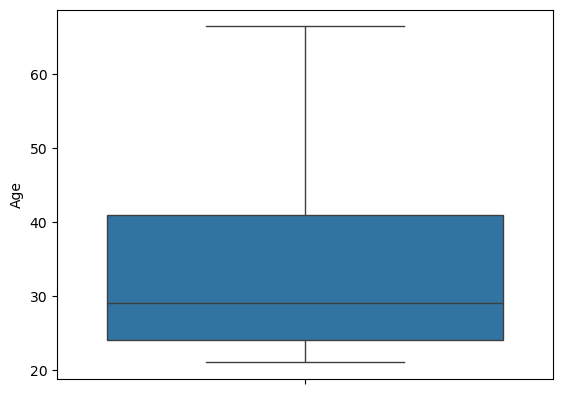

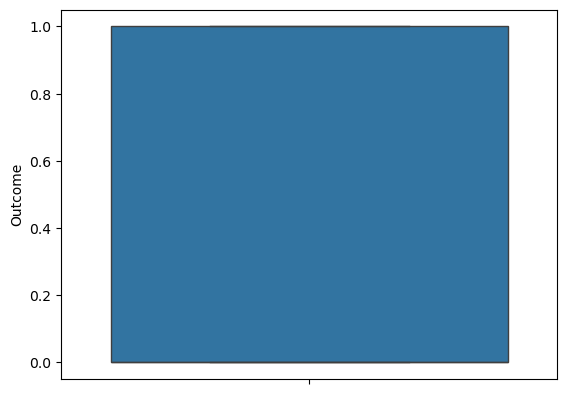

In [10]:
for col in Data.columns:
    sns.boxplot(data=Data,y=col)
    plt.show()

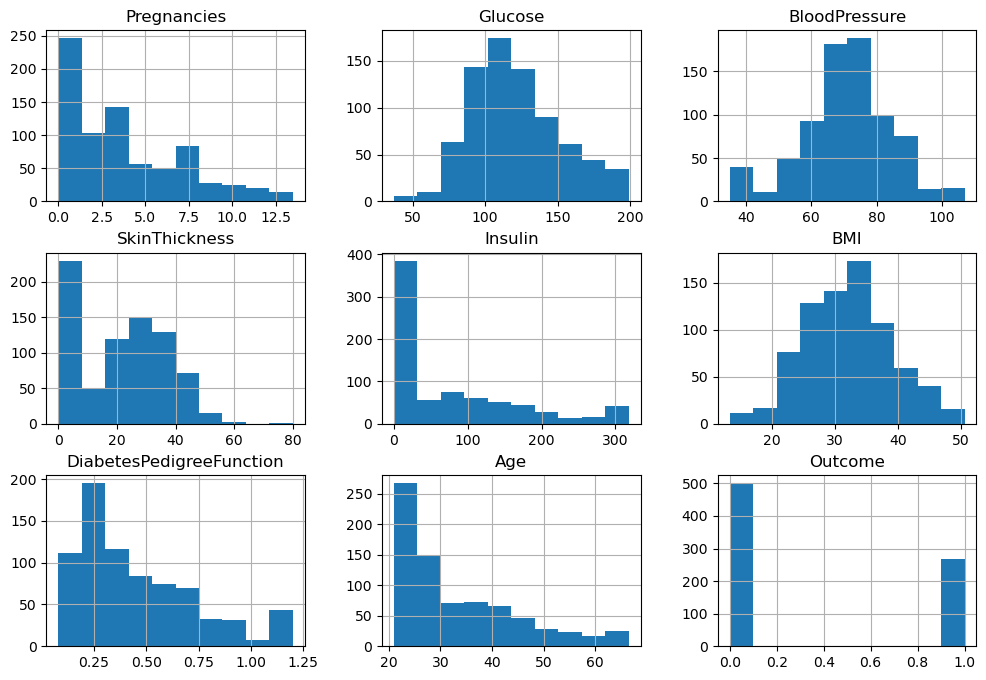

In [11]:
Data.hist(figsize=(12,8))
plt.show()

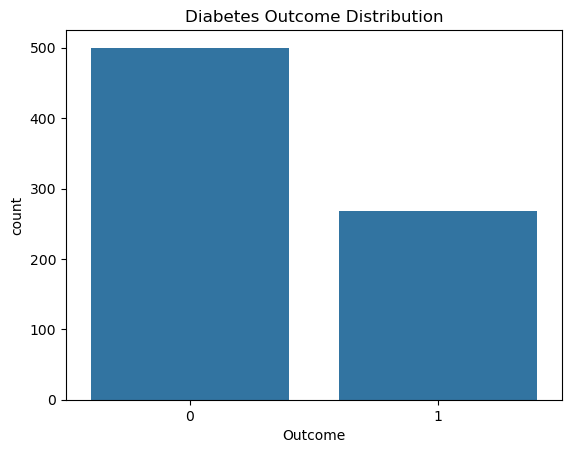

In [12]:
sns.countplot(x='Outcome', data=Data)
plt.title("Diabetes Outcome Distribution")
plt.show()

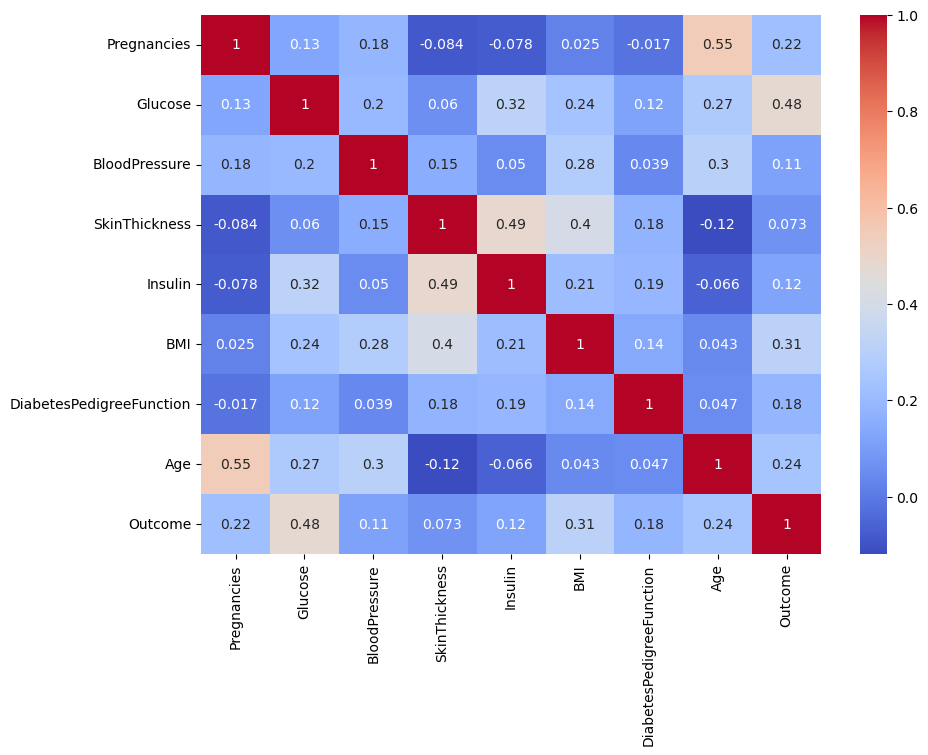

In [13]:
plt.figure(figsize=(10,7))
sns.heatmap(Data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [14]:
target=Data[['Outcome']]
features=Data.drop(columns=['Outcome'])
features.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0


In [15]:
f_clas = f_classif(features,target)
pd.Series(f_clas[0],index=features.columns).sort_values(ascending=False)

Glucose                     228.278996
BMI                          81.287147
Age                          47.944757
Pregnancies                  39.106100
DiabetesPedigreeFunction     27.135876
Insulin                      12.103615
BloodPressure                 9.961146
SkinThickness                 4.118049
dtype: float64

In [16]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=200)
print(x_train.shape)
print(x_test.shape)
print(x_train.shape)
print(x_train.shape)

(614, 8)
(154, 8)
(614, 8)
(614, 8)


In [17]:
std_sca=StandardScaler()
x_train[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]=std_sca.fit_transform(x_train[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']])

In [18]:
x_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
310,0.661302,-1.320538,-0.359458,0.627897,-0.784555,-0.853617,-0.516159,0.691120
478,1.259959,0.148987,0.218499,1.144692,0.017453,-0.896514,-1.049793,0.517864
45,-1.134670,1.874082,-0.359458,1.209291,-0.784555,1.405647,2.618497,-0.694929
677,-1.134670,-0.905238,-0.792926,-1.310083,-0.784555,0.447605,-0.692859,-0.694929
453,-0.536013,-0.074637,-2.599041,-1.310083,-0.784555,-1.797359,1.317985,2.900135


In [19]:
x_test[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]=std_sca.transform(x_test[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']])

In [20]:
x_test.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
355,1.559288,1.394889,1.229923,-1.310083,-0.784555,-0.253053,-0.555033,1.384144
667,1.858617,-0.330206,-0.070480,0.434099,-0.784555,-0.667728,-1.124007,0.604492
390,-0.835342,-0.681614,-0.359458,0.563298,1.311360,-0.024267,-0.053206,0.777748
356,-0.835342,0.117041,-1.515372,1.273890,1.001250,0.161622,1.777405,-0.435045
269,-0.536013,0.787911,-2.599041,-1.310083,-0.784555,-0.667728,-0.774141,-0.435045


In [21]:
## Model Building

In [22]:
log_model = LogisticRegression()
log_model.fit(x_train,y_train)

LogisticRegression()

In [23]:
y_pred = log_model.predict(x_test)
accuracy_score(y_test,y_pred)

0.8376623376623377

In [24]:
y_prob = log_model.predict_proba(x_test)[:,1]
y_prob

array([0.75019832, 0.24558383, 0.13064383, 0.43803475, 0.40789895,
       0.29710031, 0.73840918, 0.4585959 , 0.6041195 , 0.57859617,
       0.21398789, 0.11725193, 0.78966227, 0.94437035, 0.33957583,
       0.90473401, 0.94924739, 0.95103527, 0.45235399, 0.14084429,
       0.67518681, 0.1204057 , 0.28934867, 0.02284663, 0.28649545,
       0.57559881, 0.34344974, 0.23360835, 0.02849969, 0.26038559,
       0.29170437, 0.1327451 , 0.10288677, 0.35803416, 0.10813225,
       0.16534526, 0.35570544, 0.0238428 , 0.08298119, 0.50819412,
       0.9667338 , 0.04344694, 0.58010731, 0.23731402, 0.12695407,
       0.33179385, 0.17984167, 0.7914609 , 0.08463103, 0.88710438,
       0.78970713, 0.22336396, 0.46589567, 0.01866538, 0.67572511,
       0.15705869, 0.1400485 , 0.89112559, 0.29768066, 0.06434219,
       0.31384994, 0.32916249, 0.12145484, 0.10269224, 0.82367251,
       0.16856062, 0.0488383 , 0.37561287, 0.21204265, 0.1249892 ,
       0.16496717, 0.45795431, 0.72479483, 0.24519602, 0.71945

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8376623376623377
Precision: 0.7948717948717948
Recall: 0.6458333333333334
F1 Score: 0.7126436781609196
ROC-AUC: 0.8596698113207547


In [27]:
from sklearn.metrics import confusion_matrix,classification_report

In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.89       106
           1       0.79      0.65      0.71        48

    accuracy                           0.84       154
   macro avg       0.82      0.79      0.80       154
weighted avg       0.83      0.84      0.83       154



In [29]:
from sklearn.metrics import roc_auc_score, roc_curve

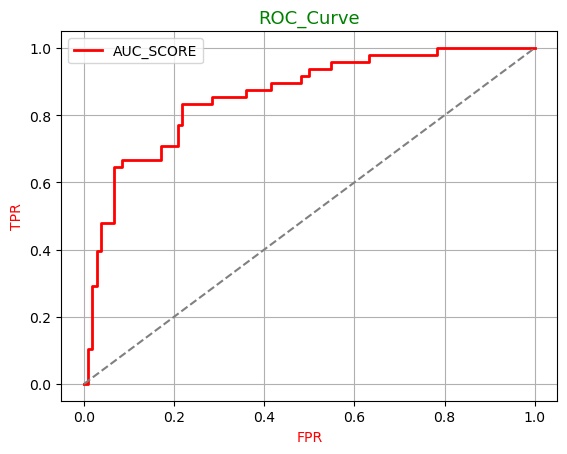

In [30]:
fpr,tpr,thr=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,lw=2,color='red',label= f'AUC_SCORE')
plt.plot([0,1],linestyle='--',color='grey')
plt.xlabel('FPR',color='red',size=10)
plt.ylabel('TPR',color='red',size=10)
plt.title('ROC_Curve',color='green',size=13)
plt.legend()
plt.grid();

In [31]:
coeff_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coeff_df

,Feature,Coefficient
1,Glucose,1.106267
5,BMI,0.678605
0,Pregnancies,0.362998
6,DiabetesPedigreeFunction,0.340106
7,Age,0.168743
3,SkinThickness,-0.015598
4,Insulin,-0.134249
2,BloodPressure,-0.162612


In [32]:
log_model.coef_

array([[ 0.36299765,  1.10626652, -0.16261215, -0.01559782, -0.13424921,
         0.67860547,  0.34010617,  0.16874286]])

In [33]:
import pickle

In [34]:
file = 'Logistic_model.pkl'

In [35]:
pickle.dump(log_model,open(file,'wb'))

In [36]:
file1 = 'std_sca.pkl'

In [37]:
pickle.dump(std_sca,open(file1,'wb'))

In [38]:
# you can check, i am creating a Streamlit app in Python that involves loading my trained model and setting up user inputs for predictions:
# I making different file for Model_Diployment for better understanding.
# http://localhost:8501 <<< That is link for confirmation, i have deployed my model successfully.

### Interview Question

In [39]:
## 1. What is the difference between precision and recall?
## 1. Precision
# Definition: Precision is the proportion of correctly predicted positive observations out of all observations predicted as positive.

# Formula: Precision = True Positives(TP) /True Positives (TP)+False Positives (FP)

# Interpretation:
# Out of all the positive labels the model predicted, how many were actually correct?

# High Precision: Few false positives.

## 2. Recall (Sensitivity or True Positive Rate)
# Definition: Recall is the proportion of correctly predicted positive observations out of all actual positive observations.

# Formula: Recall = True Positives (TP) / True Positives (TP)+False Negatives (FN)

# Interpretation:
# Out of all the actual positive cases, how many did the model correctly identify?

# High Recall: Few false negatives

In [40]:
## 2. What is cross-validation, and why is it important in binary classification?
# Cross-validation is a technique to evaluate model performance more reliably by splitting the data into multiple parts.
# Most Common Type: K-Fold Cross-Validation
# Split the dataset into K equal parts (folds).
# For each fold:
# Use K-1 folds for training.
# Use 1 fold for testing/validation.
# Repeat K times, each time with a different fold used as the validation set.
# Average the results to get a more reliable estimate of model performance

In [41]:
##  Why is Cross-Validation Important in Binary Classification
# Avoids Overfitting
# Training on only one split may cause the model to perform well there but poorly on unseen data.
# Cross-validation tests on multiple splits, ensuring the model is not memorizing the data.

# Gives Reliable Performance Metrics
# For binary classification, metrics like accuracy, precision, recall, F1-score, and AUC can vary across splits.
# Cross-validation gives an average, which is more stable and trustworthy.

# Handles Imbalanced Datasets
# Using Stratified K-Fold ensures each fold has a similar proportion of positive and negative classes, which is crucial in binary classification (e.g., spam vs. not spam, disease vs. no disease).

# Model Selection and Hyperparameter Tuning
# When tuning models using techniques like GridSearchCV or RandomizedSearchCV, cross-validation helps compare models fairly and robustly.